<a href="https://colab.research.google.com/github/luisgabrielmatthew74/codeprojects/blob/main/docs/simulate/quantum_virtual_machine-v11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2022 The Cirq Developers

## Informe Resumen de Métricas Clave de la Red

### 1. Conteo de Elementos de la Red

In [44]:
num_aristas = len(df_aristas_cleaned)
num_nodos = len(df_nodos_cleaned)

print(f"Número total de Aristas (Enlaces): {num_aristas}")
print(f"Número total de Nodos: {num_nodos}")

Número total de Aristas (Enlaces): 200
Número total de Nodos: 60


### 2. Estadísticas de Capacidad (Gbps)

In [45]:
print('Estadísticas de Capacidad (Gbps) en Aristas:')
display(df_aristas_cleaned['Capacidad (Gbps)'].describe())

print('\nEstadísticas de Capacidad (Gbps) en Nodos:')
display(df_nodos_cleaned['Capacidad (Gbps)'].describe())

Estadísticas de Capacidad (Gbps) en Aristas:


,Capacidad (Gbps)
count,200.000000
mean,322.600000
std,238.152943
min,40.000000
25%,40.000000
50%,400.000000
75%,400.000000
max,1000.000000



Estadísticas de Capacidad (Gbps) en Nodos:


,Capacidad (Gbps)
count,60.000000
mean,1422.733333
std,1490.480515
min,101.000000
25%,311.750000
50%,537.500000
75%,2026.750000
max,4993.000000


### 3. Distribución de Criticidad

In [46]:
print('Distribución de Criticidad en Aristas:')
display(df_aristas_cleaned['Criticidad'].value_counts())

print('\nDistribución de Criticidad en Nodos:')
display(df_nodos_cleaned['Criticidad'].value_counts())

Distribución de Criticidad en Aristas:


,count
Criticidad,
Media-Alta,125
Media,63
Alta,12



Distribución de Criticidad en Nodos:


,count
Criticidad,
Alta,20
Baja-Media,16
Media,14
Media-Alta,10


### 4. Distribución por Medio Físico (Aristas) y Tipo de Hardware (Nodos)

### Búsqueda de Ruta de Contingencia

In [52]:
# Crear una copia del grafo para no modificar el original
G_contingency = G.copy()

# Identificar el tramo crítico a evitar (la arista directa entre V0_Paracho y V5_Netflix)
critical_edge = ('V0_Paracho', 'V5_Netflix')

# Eliminar el tramo crítico si existe
if G_contingency.has_edge(*critical_edge):
    G_contingency.remove_edge(*critical_edge)
    print(f"Tramo crítico {critical_edge} eliminado para la búsqueda de contingencia.")
else:
    print(f"El tramo crítico {critical_edge} no existe o ya ha sido eliminado.")

# Calcular el nuevo camino más corto por Latencia en el grafo modificado
source_node = 'V0_Paracho'
target_node = 'V5_Netflix'

print(f"\n--- Buscando camino de contingencia (por Latencia) entre {source_node} y {target_node} ---")
try:
    alternative_path_nodes = nx.shortest_path(G_contingency, source=source_node, target=target_node, weight='Latency')
    alternative_path_latency = nx.shortest_path_length(G_contingency, source=source_node, target=target_node, weight='Latency')
    print(f"Camino de contingencia: {alternative_path_nodes}")
    print(f"Latencia total del camino de contingencia: {alternative_path_latency:.2f} ms")

    # Comparar con la ruta original
    if 'shortest_path_latency_length' in locals(): # Check if original path length exists from previous execution
        print(f"\nComparación con la ruta original (directa): {shortest_path_latency_length:.2f} ms")
        print(f"La ruta de contingencia es {alternative_path_latency - shortest_path_latency_length:.2f} ms más larga.")

except nx.NetworkXNoPath:
    print(f"No hay camino de contingencia entre {source_node} y {target_node} después de eliminar el tramo crítico.")

Tramo crítico ('V0_Paracho', 'V5_Netflix') eliminado para la búsqueda de contingencia.

--- Buscando camino de contingencia (por Latencia) entre V0_Paracho y V5_Netflix ---
Camino de contingencia: ['V0_Paracho', 'Router_Acceso_14', 'CDN_Cache_6', 'Troncal_ISP_5', 'V5_Netflix']
Latencia total del camino de contingencia: 35.00 ms

Comparación con la ruta original (directa): 10.00 ms
La ruta de contingencia es 25.00 ms más larga.


### Análisis de Robustez: Eliminación de Nodos Críticos

In [53]:
# Identificar nodos críticos (por ejemplo, Criticidad_Num >= 3, que corresponde a 'Alta' o 'Muy Alta')
critical_nodes_df = df_nodos_cleaned[df_nodos_cleaned['Criticidad_Num'] >= 3]
critical_node_ids = critical_nodes_df['ID Nodo'].tolist()

print(f"Nodos identificados como críticos (Criticidad >= 'Alta'): {critical_node_ids}")

results_robustness = []
original_source = 'V0_Paracho'
original_target = 'V5_Netflix'

# Calcular la latencia original del camino más corto para referencia
try:
    original_shortest_path_latency = nx.shortest_path_length(G, source=original_source, target=original_target, weight='Latency')
    print(f"\nLatencia original del camino más corto entre {original_source} y {original_target}: {original_shortest_path_latency:.2f} ms")
except nx.NetworkXNoPath:
    original_shortest_path_latency = float('inf')
    print(f"\nNo hay camino entre {original_source} y {original_target} en el grafo original.")

for node_to_remove in critical_node_ids:
    G_robustness = G.copy() # Crear una copia del grafo original

    if G_robustness.has_node(node_to_remove):
        G_robustness.remove_node(node_to_remove)
        print(f"\n--- Nodo '{node_to_remove}' eliminado ---")
    else:
        print(f"\n--- El nodo '{node_to_remove}' no existe en el grafo. ---")
        continue

    try:
        # Recalcular el camino más corto por latencia
        new_path_latency = nx.shortest_path_length(G_robustness, source=original_source, target=original_target, weight='Latency')
        new_path_nodes = nx.shortest_path(G_robustness, source=original_source, target=original_target, weight='Latency')
        status = f"{new_path_latency:.2f} ms"
        path_found = True
        print(f"Nuevo camino más corto: {new_path_nodes}")
        print(f"Nueva latencia: {new_path_latency:.2f} ms")
    except nx.NetworkXNoPath:
        new_path_latency = float('inf')
        status = "No hay camino"
        path_found = False
        print(f"No hay camino entre {original_source} y {original_target} después de eliminar {node_to_remove}.")

    results_robustness.append({
        'Nodo Eliminado': node_to_remove,
        'Latencia Original': f"{original_shortest_path_latency:.2f} ms",
        'Nueva Latencia': status,
        'Diferencia Latencia': f"{new_path_latency - original_shortest_path_latency:.2f} ms" if path_found else 'N/A',
        'Conectado': path_found
    })

df_robustness_results = pd.DataFrame(results_robustness)
print("\n--- Resumen del Análisis de Robustez ---")
display(df_robustness_results)

Nodos identificados como críticos (Criticidad >= 'Alta'): ['V2_Morelia', 'V2_Uruapan', 'V3_ISP_CDMX', 'V4_IXP_MÉX', 'V5_Google', 'V5_Netflix', 'Troncal_ISP_1', 'Troncal_ISP_2', 'Troncal_ISP_3', 'Troncal_ISP_4', 'Troncal_ISP_5', 'Troncal_ISP_6', 'Troncal_ISP_7', 'Troncal_ISP_8', 'Troncal_ISP_9', 'Troncal_ISP_10', 'Troncal_ISP_11', 'Troncal_ISP_12', 'Troncal_ISP_13', 'Troncal_ISP_14']

Latencia original del camino más corto entre V0_Paracho y V5_Netflix: 10.00 ms

--- Nodo 'V2_Morelia' eliminado ---
Nuevo camino más corto: ['V0_Paracho', 'V5_Netflix']
Nueva latencia: 10.00 ms

--- Nodo 'V2_Uruapan' eliminado ---
Nuevo camino más corto: ['V0_Paracho', 'V5_Netflix']
Nueva latencia: 10.00 ms

--- Nodo 'V3_ISP_CDMX' eliminado ---
Nuevo camino más corto: ['V0_Paracho', 'V5_Netflix']
Nueva latencia: 10.00 ms

--- Nodo 'V4_IXP_MÉX' eliminado ---
Nuevo camino más corto: ['V0_Paracho', 'V5_Netflix']
Nueva latencia: 10.00 ms

--- Nodo 'V5_Google' eliminado ---
Nuevo camino más corto: ['V0_Paracho'

,Nodo Eliminado,Latencia Original,Nueva Latencia,Diferencia Latencia,Conectado
0,V2_Morelia,10.00 ms,10.00 ms,0.00 ms,True
1,V2_Uruapan,10.00 ms,10.00 ms,0.00 ms,True
2,V3_ISP_CDMX,10.00 ms,10.00 ms,0.00 ms,True
3,V4_IXP_MÉX,10.00 ms,10.00 ms,0.00 ms,True
4,V5_Google,10.00 ms,10.00 ms,0.00 ms,True
5,V5_Netflix,10.00 ms,No hay camino,N/A,False
6,Troncal_ISP_1,10.00 ms,10.00 ms,0.00 ms,True
7,Troncal_ISP_2,10.00 ms,10.00 ms,0.00 ms,True
8,Troncal_ISP_3,10.00 ms,10.00 ms,0.00 ms,True
9,Troncal_ISP_4,10.00 ms,10.00 ms,0.00 ms,True


### Simulación de Montecarlo: Análisis de Degradación de la Red por Fallos Aleatorios de Enlaces

In [54]:
import random

# Definir los nodos de origen y destino para el análisis de conectividad
source_node_mc = 'V0_Paracho'
target_node_mc = 'V5_Netflix'

# Número de simulaciones a realizar
num_simulations = 100

# Lista para almacenar el número de enlaces que fallaron antes de la desconexión
disconnections_count = []

print(f"Iniciando simulación de Montecarlo para analizar la desconexión entre {source_node_mc} y {target_node_mc}...")

for i in range(num_simulations):
    G_sim = G.copy()  # Trabajar con una copia del grafo original en cada simulación
    all_edges = list(G_sim.edges()) # Obtener todas las aristas del grafo
    random.shuffle(all_edges) # Aleatorizar el orden de las aristas

    edges_removed = 0
    is_connected = True

    for edge in all_edges:
        if G_sim.has_edge(edge[0], edge[1]): # Verificar si la arista aún existe
            G_sim.remove_edge(edge[0], edge[1])
            edges_removed += 1

            # Verificar conectividad solo si los nodos de origen/destino siguen en el grafo
            if G_sim.has_node(source_node_mc) and G_sim.has_node(target_node_mc):
                if not nx.has_path(G_sim, source_node_mc, target_node_mc):
                    is_connected = False
                    disconnections_count.append(edges_removed)
                    break # La red se ha desconectado, pasar a la siguiente simulación
            else:
                # Si un nodo es eliminado porque era parte de un edge, consideramos que ya no hay camino.
                # Esto puede pasar si source_node_mc o target_node_mc son eliminados.
                is_connected = False
                disconnections_count.append(edges_removed)
                break

    if is_connected: # Si la red nunca se desconectó (caso raro si hay muchas aristas)
        disconnections_count.append(edges_removed) # Se eliminaron todas las aristas y nunca se desconectó

    if (i + 1) % 10 == 0:
        print(f"Simulación {i+1}/{num_simulations} completada.")

print("\nSimulación de Montecarlo finalizada.")

# Convertir a DataFrame para facilitar el análisis y visualización
df_disconnections = pd.DataFrame({
    'Enlaces Eliminados': disconnections_count
})

print("\nResumen de Enlaces Eliminados antes de la Desconexión:")
display(df_disconnections.describe())


Iniciando simulación de Montecarlo para analizar la desconexión entre V0_Paracho y V5_Netflix...
Simulación 10/100 completada.
Simulación 20/100 completada.
Simulación 30/100 completada.
Simulación 40/100 completada.
Simulación 50/100 completada.
Simulación 60/100 completada.
Simulación 70/100 completada.
Simulación 80/100 completada.
Simulación 90/100 completada.
Simulación 100/100 completada.

Simulación de Montecarlo finalizada.

Resumen de Enlaces Eliminados antes de la Desconexión:


,Enlaces Eliminados
count,100.000000
mean,152.840000
std,20.672394
min,91.000000
25%,140.750000
50%,153.000000
75%,165.250000
max,197.000000


Ahora, visualicemos la distribución de estos resultados para entender cuántos fallos aleatorios son necesarios para desconectar la red.

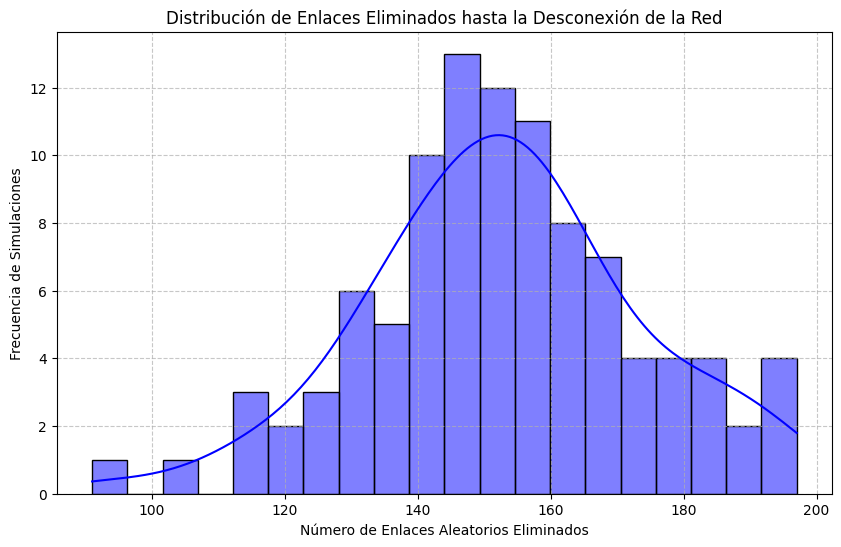

In [55]:
plt.figure(figsize=(10, 6))
sns.histplot(df_disconnections['Enlaces Eliminados'], kde=True, bins=20, color='blue')
plt.title('Distribución de Enlaces Eliminados hasta la Desconexión de la Red')
plt.xlabel('Número de Enlaces Aleatorios Eliminados')
plt.ylabel('Frecuencia de Simulaciones')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### Simulación de Robustez: Fallo Dirigido por Criticidad de Enlaces

In [56]:
import networkx as nx

# Reutilizando definiciones de los nodos clave
source_node_critical_failure = 'V0_Paracho'
target_node_critical_failure = 'V5_Netflix'

G_critical_failure = G.copy()

# Extraer aristas con sus atributos para poder ordenar por criticidad
edges_with_attributes = []
for u, v, data in G_critical_failure.edges(data=True):
    criticidad = data.get('Criticidad_Num', 0)  # Asume 0 si no hay Criticidad_Num
    latency = data.get('Latency', 0)        # Asume 0 si no hay Latency
    edges_with_attributes.append((u, v, criticidad, latency))

# Ordenar aristas por Criticidad_Num (descendente), luego por Latency (descendente) como desempate
sorted_edges_criticality = sorted(edges_with_attributes, key=lambda x: (x[2], x[3]), reverse=True)

edges_removed_critical = 0
disconnection_point_critical = None
path_lost = False

print(f"Iniciando simulación de fallos por criticidad para la conexión entre {source_node_critical_failure} y {target_node_critical_failure}...")

for u, v, criticidad, latency in sorted_edges_criticality:
    if G_critical_failure.has_edge(u, v):
        G_critical_failure.remove_edge(u, v)
        edges_removed_critical += 1

        # Verificar conectividad solo si los nodos de origen/destino siguen en el grafo
        if G_critical_failure.has_node(source_node_critical_failure) and G_critical_failure.has_node(target_node_critical_failure):
            if not nx.has_path(G_critical_failure, source_node_critical_failure, target_node_critical_failure):
                disconnection_point_critical = edges_removed_critical
                path_lost = True
                print(f"Conexión perdida después de eliminar {edges_removed_critical} enlaces críticos (Cr.: {criticidad}, Lat.: {latency}ms).")
                break
        else:
            # Si un nodo clave es aislado/eliminado indirectamente al quitar un edge
            disconnection_point_critical = edges_removed_critical
            path_lost = True
            print(f"Conexión perdida porque un nodo clave fue aislado/removido después de eliminar {edges_removed_critical} enlaces críticos.")
            break

if not path_lost:
    print(f"La red nunca se desconectó después de eliminar todos los {edges_removed_critical} enlaces, lo cual es inusual.")

# Resumir resultados
print("\n--- Resumen del Análisis de Robustez por Fallos Críticos ---")
if disconnection_point_critical is not None:
    print(f"Número de enlaces eliminados (por criticidad) hasta la desconexión: {disconnection_point_critical}")
else:
    print("La conexión entre los nodos clave nunca se perdió (considerando la eliminación de todos los enlaces).")

# Comparar con la simulación de Montecarlo (asumiendo que df_disconnections está disponible)
if 'df_disconnections' in locals():
    mean_random_disconnection = df_disconnections['Enlaces Eliminados'].mean()
    std_random_disconnection = df_disconnections['Enlaces Eliminados'].std()

    print(f"\nComparación con la simulación de Montecarlo:")
    print(f"Promedio de enlaces eliminados (fallo aleatorio) hasta la desconexión: {mean_random_disconnection:.2f}")
    print(f"Número de enlaces eliminados (fallo crítico) hasta la desconexión: {disconnection_point_critical if disconnection_point_critical is not None else 'N/A'}")

    if disconnection_point_critical is not None and disconnection_point_critical < mean_random_disconnection:
        print(f"La red es significativamente más vulnerable a fallos dirigidos a enlaces críticos, desconectándose con {mean_random_disconnection - disconnection_point_critical:.2f} menos enlaces que en un escenario aleatorio promedio.")
    elif disconnection_point_critical is not None:
        print(f"La red parece ser igualmente o menos vulnerable a fallos dirigidos a enlaces críticos, desconectándose con {disconnection_point_critical - mean_random_disconnection:.2f} más enlaces que en un escenario aleatorio promedio (lo cual sería inusual). ")
else:
    print("\nNo se pudo comparar con la simulación de Montecarlo porque los resultados no están disponibles.")


Iniciando simulación de fallos por criticidad para la conexión entre V0_Paracho y V5_Netflix...
Conexión perdida después de eliminar 186 enlaces críticos (Cr.: 1.0, Lat.: 10.0ms).

--- Resumen del Análisis de Robustez por Fallos Críticos ---
Número de enlaces eliminados (por criticidad) hasta la desconexión: 186

Comparación con la simulación de Montecarlo:
Promedio de enlaces eliminados (fallo aleatorio) hasta la desconexión: 152.84
Número de enlaces eliminados (fallo crítico) hasta la desconexión: 186
La red parece ser igualmente o menos vulnerable a fallos dirigidos a enlaces críticos, desconectándose con 33.16 más enlaces que en un escenario aleatorio promedio (lo cual sería inusual). 


### Clasificación de Robustez de Nodos con GCN (como aproximación a FastGTN)

Para esta tarea, utilizaremos un modelo de aprendizaje profundo sobre grafos. Como **FastGTN** es una arquitectura avanzada que podría requerir una implementación más extensa o librerías específicas, comenzaremos con un modelo **Graph Convolutional Network (GCN)**, que es un estándar en la clasificación de nodos y nos permitirá establecer una línea base y entender el proceso. Si lo deseas, podemos explorar una implementación de FastGTN o modelos más complejos después.

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# --- 1. Preparación de los datos ---

# Definir el objetivo: 'robustez media-alta' (Criticidad_Num = 2)
# Creamos una columna binaria: 1 si Criticidad_Num es 2, 0 en otro caso.
# Consideramos que G está definido y df_nodos_cleaned está disponible del contexto anterior.

# Mapear los nodos en G a índices numéricos consecutivos para torch_geometric
node_mapping = {node: i for i, node in enumerate(G.nodes())}
node_features = []
node_labels = []

# Crear el target 'is_media_alta_robustez'
df_nodos_cleaned['is_media_alta_robustez'] = (df_nodos_cleaned['Criticidad_Num'] == 2).astype(int)

# Seleccionar y procesar características de los nodos
# Características numéricas
numerical_features = ['Capacidad (Gbps)', 'Latency']
X_numerical = df_nodos_cleaned[numerical_features].values

# Estandarizar características numéricas
scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(X_numerical)

# Características categóricas (one-hot encoding)
categorical_features = ['Tipo de Hardware', 'Función Operativa', 'Ubicación']
X_categorical = pd.get_dummies(df_nodos_cleaned[categorical_features], prefix=categorical_features)

# Combinar todas las características
X = np.hstack((X_numerical_scaled, X_categorical.values))

# Asegurarse de que el orden de los nodos en X y y coincida con el orden de G.nodes()
# Crear un DataFrame con las características y el target, indexado por ID Nodo
df_features_labels = df_nodos_cleaned.set_index('ID Nodo')

# Asegurarse de que las características y etiquetas estén en el mismo orden que G.nodes()
ordered_features = []
ordered_labels = []
for node_id in G.nodes():
    if node_id in df_features_labels.index:
        ordered_features.append(X[df_nodos_cleaned['ID Nodo'] == node_id].flatten())
        ordered_labels.append(df_features_labels.loc[node_id, 'is_media_alta_robustez'])
    else:
        # Manejar nodos en G que no están en df_nodos_cleaned si es necesario
        # Por simplicidad, asumiremos que todos los nodos de G están en df_nodos_cleaned
        print(f"Advertencia: El nodo {node_id} de G no se encontró en df_nodos_cleaned.")

X = torch.tensor(np.array(ordered_features), dtype=torch.float)
y = torch.tensor(np.array(ordered_labels), dtype=torch.long)

# Crear edge_index para PyTorch Geometric
# Convertir los IDs de los nodos a los nuevos índices numéricos
edge_index_list = []
for u, v in G.edges():
    if u in node_mapping and v in node_mapping:
        edge_index_list.append([node_mapping[u], node_mapping[v]])
        edge_index_list.append([node_mapping[v], node_mapping[u]]) # Los GCN suelen trabajar con grafos no dirigidos (aristas simétricas)

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()

# Dividir los datos en conjuntos de entrenamiento, validación y prueba
# Usamos índices para la división para asegurarnos de que la división sea consistente con los tensores.
num_nodes = len(G.nodes())
all_indices = np.arange(num_nodes)

# 70% entrenamiento, 15% validación, 15% prueba
train_indices, test_indices = train_test_split(all_indices, test_size=0.3, random_state=42, stratify=y)
val_indices, test_indices = train_test_split(test_indices, test_size=0.5, random_state=42, stratify=y[test_indices])

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_indices] = True
val_mask[val_indices] = True
test_mask[test_indices] = True

# Crear el objeto Data de PyTorch Geometric
data = Data(x=X, edge_index=edge_index, y=y, train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

print("Datos preparados para GNN:")
print(f"Número de nodos: {data.num_nodes}")
print(f"Número de aristas: {data.num_edges}")
print(f"Dimensiones de las características de los nodos (X): {data.x.shape}")
print(f"Dimensiones de las etiquetas (y): {data.y.shape}")
print(f"Nodos de entrenamiento: {data.train_mask.sum().item()}")
print(f"Nodos de validación: {data.val_mask.sum().item()}")
print(f"Nodos de prueba: {data.test_mask.sum().item()}")


Datos preparados para GNN:
Número de nodos: 60
Número de aristas: 396
Dimensiones de las características de los nodos (X): torch.Size([60, 7])
Dimensiones de las etiquetas (y): torch.Size([60])
Nodos de entrenamiento: 42
Nodos de validación: 9
Nodos de prueba: 9


Ahora definiremos la arquitectura de la GCN y el proceso de entrenamiento.

### Hybrid Quantum-Classical GCN with Quantum Feature Encoder

To explore **Hybrid Quantum-Classical Approaches** and potentially achieve **better feature expressivity**, we can integrate a Quantum Feature Encoder (QFE) into our GCN. This QFE will be a Variational Quantum Circuit (VQC) that maps classical node features into a higher-dimensional quantum state, which is then fed into the classical GCN layers.

While achieving significant 'faster training' for complex neural networks on current quantum hardware is still an active research area, and 'robustness to noise' in quantum systems is complex due to inherent quantum noise, a quantum feature map can offer a richer and potentially more discriminative representation of data. This could lead to improved model performance or unique generalization properties compared to purely classical models.

We will use the PennyLane library, which provides a flexible framework for hybrid quantum-classical machine learning and integrates well with PyTorch.

In [59]:
# Install PennyLane and its PyTorch lightning plugin for fast simulation
try:
    import pennylane as qml
    from pennylane import numpy as qnp
    import pennylane.templates.layers as layers
except ImportError:
    print("Installing PennyLane...")
    !pip install --quiet pennylane pennylane-lightning[torch]
    print("PennyLane installed.")
    import pennylane as qml
    from pennylane import numpy as qnp
    import pennylane.templates.layers as layers


Installing PennyLane...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.8 MB/s eta 0:00:00
PennyLane installed.


#### Defining the Quantum Feature Encoder (QFE)

This quantum layer will take a classical feature vector and embed it into a quantum state. We'll use a simple variational circuit for demonstration, which can be extended for more complex feature mappings.

In [64]:
import torch # Ensure torch is imported for torch.stack

class QuantumFeatureEncoder(nn.Module):
    def __init__(self, num_qubits, num_features, output_size):
        super().__init__()
        self.num_qubits = num_qubits
        self.output_size = output_size # Number of classical outputs from the quantum circuit

        # Ensure number of features matches input for embedding
        # For simplicity, we'll assume num_features <= num_qubits for direct encoding
        # Or, we can compress/expand features before embedding if needed.
        if num_features > num_qubits:
            # Example: use a linear layer to reduce feature dimension if too large
            self.pre_quantum_proj = nn.Linear(num_features, num_qubits)
            input_q_features = num_qubits
        else:
            self.pre_quantum_proj = None
            input_q_features = num_features

        # Define the quantum device
        # Using 'lightning.qubit' for high-performance CPU simulation of qubits.
        self.dev = qml.device("lightning.qubit", wires=num_qubits)

        @qml.qnode(self.dev, interface="torch", diff_method="parameter-shift")
        def quantum_circuit(inputs, weights):
            # Data encoding: Simple angle embedding
            # Map each feature to a rotation angle on a qubit
            for i in range(input_q_features):
                qml.RY(inputs[i % input_q_features], wires=i % num_qubits)

            # Variational layer: Entangling + Rotations
            # Use a template for a common variational layer
            qml.StronglyEntanglingLayers(weights, wires=range(num_qubits))

            # Measurement: Expectation value of PauliZ for each qubit
            # This extracts classical information from the quantum state
            # Explicitly stack the results into a single tensor for compatibility with TorchLayer batching
            return torch.stack([qml.expval(qml.PauliZ(i)) for i in range(self.output_size)])

        self.qlayer = qml.qnn.TorchLayer(quantum_circuit,
                                         weight_shapes={"weights": layers.StronglyEntanglingLayers.shape(n_layers=3, n_wires=num_qubits)})

    def forward(self, x):
        if self.pre_quantum_proj:
            x = self.pre_quantum_proj(x)

        # Pass features through the quantum layer
        # The quantum layer expects 1D inputs per sample, so we might need to iterate or reshape
        # For simplicity, if x is (batch_size, num_features), this will apply the quantum circuit to each row
        # assuming the qlayer is designed for batched input (PennyLane's TorchLayer handles this).
        return self.qlayer(x)

# Example usage parameters for the QFE:
NUM_QUBITS = 4 # Number of qubits for the quantum circuit
Q_OUTPUT_SIZE = 4 # Number of classical outputs from the quantum circuit

print(f"QuantumFeatureEncoder initialized with {NUM_QUBITS} qubits and {Q_OUTPUT_SIZE} output size.")

QuantumFeatureEncoder initialized with 4 qubits and 4 output size.


#### Hybrid GCN Model Definition

Now, we integrate the `QuantumFeatureEncoder` into our `GCN` model. The GCN will first process the classical features through the QFE, and then apply its classical graph convolutional layers to these quantum-enhanced features.

In [65]:
class HybridGCN(nn.Module):
    def __init__(self, num_classical_features, num_qubits, q_output_size, hidden_channels, num_classes):
        super(HybridGCN, self).__init__()
        torch.manual_seed(12345)

        # Step 1: Quantum Feature Encoder
        # The output of this layer will be the input to the first GCNConv layer
        self.qfe = QuantumFeatureEncoder(num_qubits, num_classical_features, q_output_size)

        # Step 2: Classical GCN layers, taking input from the QFE's output
        self.conv1 = GCNConv(q_output_size, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        # 1. Apply Quantum Feature Encoder
        x = self.qfe(x)

        # 2. Apply classical GCN layers
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Initialize the Hybrid GCN model
# num_node_features is the original classical feature dimension
hybrid_model = HybridGCN(num_classical_features=data.num_node_features,
                         num_qubits=NUM_QUBITS,
                         q_output_size=Q_OUTPUT_SIZE,
                         hidden_channels=16,
                         num_classes=2)

optimizer_hybrid = torch.optim.Adam(hybrid_model.parameters(), lr=0.01)
criterion_hybrid = nn.CrossEntropyLoss()

print("Hybrid GCN model initialized:")
print(hybrid_model)

def train_hybrid():
    hybrid_model.train() # Set model to training mode
    optimizer_hybrid.zero_grad() # Clear gradients
    out = hybrid_model(data.x, data.edge_index) # Forward pass
    loss = criterion_hybrid(out[data.train_mask], data.y[data.train_mask]) # Calculate loss on training data
    loss.backward() # Backward pass
    optimizer_hybrid.step() # Update weights
    return loss.item()

def evaluate_hybrid(mask):
    hybrid_model.eval() # Set model to evaluation mode
    out = hybrid_model(data.x, data.edge_index) # Forward pass
    pred = out[mask].argmax(dim=1) # Get predicted class
    labels = data.y[mask] # Get true labels

    # Calculate metrics
    acc = accuracy_score(labels.cpu(), pred.cpu())
    prec = precision_score(labels.cpu(), pred.cpu(), average='weighted', zero_division=0)
    rec = recall_score(labels.cpu(), pred.cpu(), average='weighted', zero_division=0)
    f1 = f1_score(labels.cpu(), pred.cpu(), average='weighted', zero_division=0)
    return acc, prec, rec, f1

print("\nIniciando entrenamiento del modelo Hybrid GCN...")
num_epochs_hybrid = 200 # Can adjust the number of epochs

for epoch in range(1, num_epochs_hybrid + 1):
    loss_hybrid = train_hybrid()
    train_acc_hybrid, _, _, _ = evaluate_hybrid(data.train_mask)
    val_acc_hybrid, _, _, _ = evaluate_hybrid(data.val_mask)
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss_hybrid:.4f}, Train Acc: {train_acc_hybrid:.4f}, Val Acc: {val_acc_hybrid:.4f}')

print("\nEntrenamiento del Hybrid GCN finalizado.")

# --- 3. Evaluación final en el conjunto de prueba ---
print("\nEvaluación final del Hybrid GCN en el conjunto de prueba:")
test_acc_hybrid, test_prec_hybrid, test_rec_hybrid, test_f1_hybrid = evaluate_hybrid(data.test_mask)

print(f'Precisión (Accuracy) Hybrid GCN: {test_acc_hybrid:.4f}')
print(f'Exactitud (Precision) Hybrid GCN: {test_prec_hybrid:.4f}')
print(f'Exhaustividad (Recall) Hybrid GCN: {test_rec_hybrid:.4f}')
print(f'Puntuación F1 (F1-Score) Hybrid GCN: {test_f1_hybrid:.4f}')

Hybrid GCN model initialized:
HybridGCN(
  (qfe): QuantumFeatureEncoder(
    (pre_quantum_proj): Linear(in_features=7, out_features=4, bias=True)
    (qlayer): <Quantum Torch Layer: func=quantum_circuit>
  )
  (conv1): GCNConv(4, 16)
  (conv2): GCNConv(16, 2)
)

Iniciando entrenamiento del modelo Hybrid GCN...


TypeError: expected Tensor as element 0 in argument 0, but got ExpectationMP

In [58]:
class GCN(nn.Module):
    def __init__(self, num_node_features, num_classes, hidden_channels=16):
        super(GCN, self).__init__()
        torch.manual_seed(12345) # Para reproducibilidad
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Inicializar el modelo, optimizador y función de pérdida
model = GCN(num_node_features=data.num_node_features, num_classes=2) # 2 clases: es/no es 'media-alta'
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

print("Modelo GCN inicializado:")
print(model)

def train():
    model.train() # Poner el modelo en modo entrenamiento
    optimizer.zero_grad() # Limpiar gradientes
    out = model(data.x, data.edge_index) # Forward pass
    loss = criterion(out[data.train_mask], data.y[data.train_mask]) # Calcular pérdida solo en datos de entrenamiento
    loss.backward() # Backward pass
    optimizer.step() # Actualizar pesos
    return loss.item()

def evaluate(mask):
    model.eval() # Poner el modelo en modo evaluación
    out = model(data.x, data.edge_index) # Forward pass
    pred = out[mask].argmax(dim=1) # Obtener la clase predicha
    labels = data.y[mask] # Obtener las etiquetas verdaderas

    # Calcular métricas
    acc = accuracy_score(labels.cpu(), pred.cpu())
    prec = precision_score(labels.cpu(), pred.cpu(), average='weighted', zero_division=0)
    rec = recall_score(labels.cpu(), pred.cpu(), average='weighted', zero_division=0)
    f1 = f1_score(labels.cpu(), pred.cpu(), average='weighted', zero_division=0)
    return acc, prec, rec, f1

print("\nIniciando entrenamiento del modelo GCN...")
num_epochs = 200 # Podemos ajustar el número de épocas

for epoch in range(1, num_epochs + 1):
    loss = train()
    train_acc, _, _, _ = evaluate(data.train_mask)
    val_acc, _, _, _ = evaluate(data.val_mask)
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

print("\nEntrenamiento finalizado.")

# --- 3. Evaluación final en el conjunto de prueba ---
print("\nEvaluación final en el conjunto de prueba:")
test_acc, test_prec, test_rec, test_f1 = evaluate(data.test_mask)

print(f'Precisión (Accuracy): {test_acc:.4f}')
print(f'Exactitud (Precision): {test_prec:.4f}')
print(f'Exhaustividad (Recall): {test_rec:.4f}')
print(f'Puntuación F1 (F1-Score): {test_f1:.4f}')


Modelo GCN inicializado:
GCN(
  (conv1): GCNConv(7, 16)
  (conv2): GCNConv(16, 2)
)

Iniciando entrenamiento del modelo GCN...
Epoch: 010, Loss: 0.4021, Train Acc: 0.8333, Val Acc: 0.7778
Epoch: 020, Loss: 0.3888, Train Acc: 0.8333, Val Acc: 0.7778
Epoch: 030, Loss: 0.3404, Train Acc: 0.8333, Val Acc: 0.7778
Epoch: 040, Loss: 0.3343, Train Acc: 0.8333, Val Acc: 0.7778
Epoch: 050, Loss: 0.3467, Train Acc: 0.8333, Val Acc: 0.7778
Epoch: 060, Loss: 0.3132, Train Acc: 0.8333, Val Acc: 0.7778
Epoch: 070, Loss: 0.3321, Train Acc: 0.8333, Val Acc: 0.7778
Epoch: 080, Loss: 0.3295, Train Acc: 0.8333, Val Acc: 0.6667
Epoch: 090, Loss: 0.2767, Train Acc: 0.8571, Val Acc: 0.7778
Epoch: 100, Loss: 0.3011, Train Acc: 0.8571, Val Acc: 0.6667
Epoch: 110, Loss: 0.2764, Train Acc: 0.8571, Val Acc: 0.6667
Epoch: 120, Loss: 0.2764, Train Acc: 0.8571, Val Acc: 0.6667
Epoch: 130, Loss: 0.2905, Train Acc: 0.8333, Val Acc: 0.6667
Epoch: 140, Loss: 0.2674, Train Acc: 0.8333, Val Acc: 0.6667
Epoch: 150, Loss: 0

## Camino Más Corto Entre Nodos Específicos

In [49]:
source_node = 'V0_Paracho'
target_node = 'V5_Netflix'

# 1. Camino más corto por número de saltos (sin peso)
print(f"\n--- Camino más corto (por número de saltos) entre {source_node} y {target_node} ---")
try:
    shortest_path_hops = nx.shortest_path(G, source=source_node, target=target_node)
    shortest_path_hops_length = nx.shortest_path_length(G, source=source_node, target=target_node)
    print(f"Camino: {shortest_path_hops}")
    print(f"Longitud del camino (número de saltos): {shortest_path_hops_length}")
except nx.NetworkXNoPath:
    print(f"No hay camino entre {source_node} y {target_node}.")

# 2. Camino más corto por Latencia (usando 'Latency' como peso)
print(f"\n--- Camino más corto (por Latencia) entre {source_node} y {target_node} ---")
try:
    # Para encontrar el camino más corto basado en un atributo de arista (como 'Latency'),
    # usamos el algoritmo de Dijkstra.
    # El peso se pasa como el nombre del atributo de la arista.
    shortest_path_latency = nx.shortest_path(G, source=source_node, target=target_node, weight='Latency')
    shortest_path_latency_length = nx.shortest_path_length(G, source=source_node, target=target_node, weight='Latency')
    print(f"Camino: {shortest_path_latency}")
    print(f"Latencia total del camino: {shortest_path_latency_length:.2f} ms")
except nx.NetworkXNoPath:
    print(f"No hay camino entre {source_node} y {target_node} considerando la Latencia.")


--- Camino más corto (por número de saltos) entre V0_Paracho y V5_Netflix ---
Camino: ['V0_Paracho', 'V5_Netflix']
Longitud del camino (número de saltos): 1

--- Camino más corto (por Latencia) entre V0_Paracho y V5_Netflix ---
Camino: ['V0_Paracho', 'V5_Netflix']
Latencia total del camino: 10.00 ms


## Modelado del Grafo G=(V,E)

In [48]:
import networkx as nx

# Crear un grafo vacío
G = nx.Graph()

# Añadir nodos con sus atributos
for index, row in df_nodos_cleaned.iterrows():
    node_id = row['ID Nodo']
    attributes = row.drop('ID Nodo').to_dict()
    G.add_node(node_id, **attributes)

# Añadir aristas con sus atributos
for index, row in df_aristas_cleaned.iterrows():
    source = row['Source']
    target = row['Target']
    # Eliminar 'Source' y 'Target' de los atributos para no duplicarlos como atributos de arista
    attributes = row.drop(['Source', 'Target']).to_dict()
    G.add_edge(source, target, **attributes)

print(f"Grafo creado con {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")

# Mostrar algunos atributos de un nodo de ejemplo
print('\nAtributos del nodo de ejemplo (V0_Paracho):')
if 'V0_Paracho' in G:
    display(G.nodes['V0_Paracho'])

# Mostrar algunos atributos de una arista de ejemplo
print('\nAtributos de una arista de ejemplo (Troncal_ISP_5 - V5_Netflix):')
if G.has_edge('Troncal_ISP_5', 'V5_Netflix'):
    display(G.get_edge_data('Troncal_ISP_5', 'V5_Netflix'))

Grafo creado con 60 nodos y 198 aristas.

Atributos del nodo de ejemplo (V0_Paracho):


{'Tipo de Hardware': 'Router_Acceso_Regional',
 'Función Operativa': 'Enrutamiento',
 'Ubicación': 'Red',
 'Capacidad (Gbps)': 202.0,
 'Latency': 6.98,
 'Criticidad': 'Baja-Media',
 'Criticidad_Num': 0.5}


Atributos de una arista de ejemplo (Troncal_ISP_5 - V5_Netflix):


{'ID Enlace': 'E_001',
 'Medio Físico': 'Fibra Óptica Multimodo (Distribución)',
 'Categoría de Red': 'Distribución',
 'Métrica de Peso': 1,
 'Capacidad (Gbps)': 400.0,
 'Capacidad (Mbps)': 400000.0,
 'Latency': 2.5,
 'Criticidad': 'Media-Alta',
 'Criticidad_Num': 2.0}

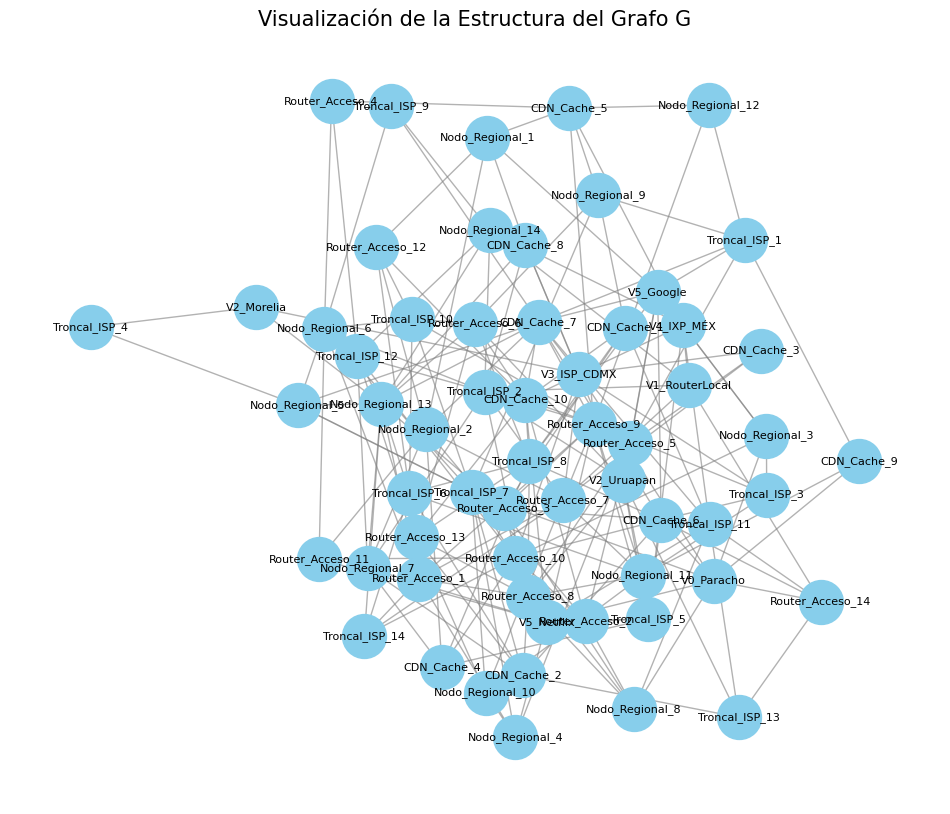

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.15, iterations=50) # Mayor k para expandir el grafo, más iteraciones para estabilidad

# Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=1000)

# Dibujar aristas
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6)

# Etiquetas de los nodos
nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')

plt.title('Visualización de la Estructura del Grafo G', size=15)
plt.axis('off') # Ocultar ejes
plt.show()

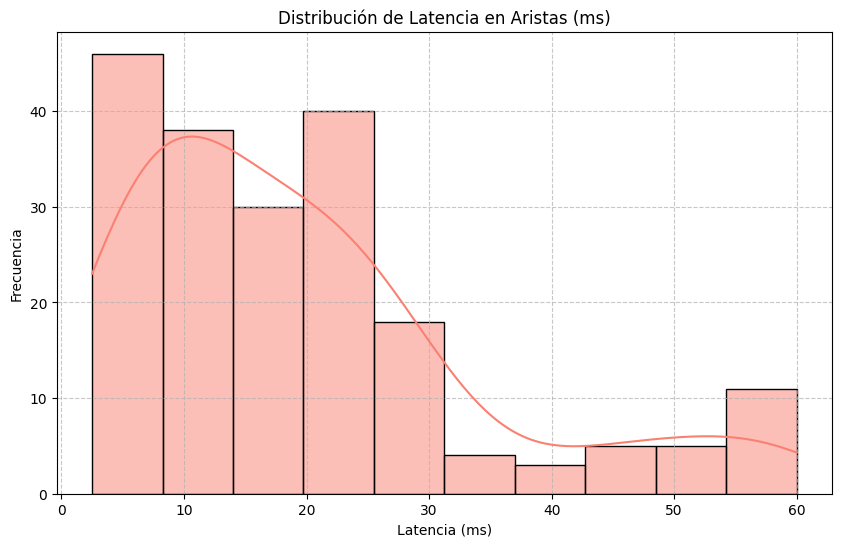

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(df_aristas_cleaned['Latency'], kde=True, bins=10, color='salmon')
plt.title('Distribución de Latencia en Aristas (ms)')
plt.xlabel('Latencia (ms)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [47]:
print('Distribución por Medio Físico en Aristas:')
display(df_aristas_cleaned['Medio Físico'].value_counts())

print('\nDistribución por Tipo de Hardware en Nodos:')
display(df_nodos_cleaned['Tipo de Hardware'].value_counts())

Distribución por Medio Físico en Aristas:


,count
Medio Físico,
Fibra Óptica Multimodo (Distribución),125
Cable de Cobre / Par Trenzado Cat8,63
Fibra Óptica Monomodo (Core),12



Distribución por Tipo de Hardware en Nodos:


,count
Tipo de Hardware,
Router_Acceso_Regional,30
Router_Core_Troncal,18
Servidor_CDN,12


### Data Cleaning and Preprocessing

In [39]:
# Clean df_aristas
df_aristas_cleaned = df_aristas.rename(columns={
    'ID_Componente': 'ID Enlace',
    'Origen_u_Fila': 'Source',
    'Destino_v_Fila': 'Target',
    'Medio_o_Tipo': 'Medio Físico',
    'Funcion_en_Red': 'Categoría de Red',
    'Metrica_Peso_o_Ubicacion': 'Métrica de Peso',
    'Capacidad_Gbps': 'Capacidad (Gbps)',
    'Latencia_ms': 'Latency',
    'Importancia_Critica': 'Criticidad'
})

criticidad_mapping = {'Baja': 0, 'Baja-Media': 0.5, 'Media': 1, 'Media-Alta': 2, 'Alta': 3, 'Muy Alta': 4}
df_aristas_cleaned['Criticidad_Num'] = df_aristas_cleaned['Criticidad'].map(criticidad_mapping)

# Create 'Capacidad (Mbps)' column (1 Gbps = 1000 Mbps)
df_aristas_cleaned['Capacidad (Mbps)'] = df_aristas_cleaned['Capacidad (Gbps)'] * 1000

df_aristas_cleaned = df_aristas_cleaned[['ID Enlace', 'Source', 'Target', 'Medio Físico', 'Categoría de Red',
                                         'Métrica de Peso', 'Capacidad (Gbps)', 'Capacidad (Mbps)', 'Latency', 'Criticidad', 'Criticidad_Num']]


# Clean df_nodos
df_nodos_cleaned = df_nodos.rename(columns={
    'ID_Componente': 'ID Nodo',
    'Medio_o_Tipo': 'Tipo de Hardware',
    'Funcion_en_Red': 'Función Operativa',
    'Metrica_Peso_o_Ubicacion': 'Ubicación',
    'Capacidad_Gbps': 'Capacidad (Gbps)',
    'Latencia_ms': 'Latency',
    'Importancia_Critica': 'Criticidad'
})

df_nodos_cleaned['Criticidad_Num'] = df_nodos_cleaned['Criticidad'].map(criticidad_mapping)

df_nodos_cleaned = df_nodos_cleaned[['ID Nodo', 'Tipo de Hardware', 'Función Operativa', 'Ubicación',
                                     'Capacidad (Gbps)', 'Latency', 'Criticidad', 'Criticidad_Num']]

print('First 5 rows of df_aristas_cleaned:')
display(df_aristas_cleaned.head())

print('\nFirst 5 rows of df_nodos_cleaned:')
display(df_nodos_cleaned.head())

First 5 rows of df_aristas_cleaned:


,ID Enlace,Source,Target,Medio Físico,Categoría de Red,Métrica de Peso,Capacidad (Gbps),Capacidad (Mbps),Latency,Criticidad,Criticidad_Num
0,E_001,Troncal_ISP_5,V5_Netflix,Fibra Óptica Multimodo (Distribución),Distribución,1,400.0,400000.0,2.5,Media-Alta,2.0
1,E_002,Troncal_ISP_12,Router_Acceso_10,Fibra Óptica Multimodo (Distribución),Distribución,4,400.0,400000.0,10.0,Media-Alta,2.0
2,E_003,Router_Acceso_7,Router_Acceso_1,Cable de Cobre / Par Trenzado Cat8,Última Milla,12,40.0,40000.0,60.0,Media,1.0
3,E_004,V5_Google,Troncal_ISP_8,Fibra Óptica Multimodo (Distribución),Distribución,12,400.0,400000.0,30.0,Media-Alta,2.0
4,E_005,CDN_Cache_8,Nodo_Regional_13,Fibra Óptica Multimodo (Distribución),Distribución,2,400.0,400000.0,5.0,Media-Alta,2.0



First 5 rows of df_nodos_cleaned:


,ID Nodo,Tipo de Hardware,Función Operativa,Ubicación,Capacidad (Gbps),Latency,Criticidad,Criticidad_Num
0,V0_Paracho,Router_Acceso_Regional,Enrutamiento,Red,202.0,6.98,Baja-Media,0.5
1,V1_RouterLocal,Router_Acceso_Regional,Enrutamiento,Red,370.0,6.66,Baja-Media,0.5
2,V2_Morelia,Router_Core_Troncal,Enrutamiento,Red,4772.0,2.19,Alta,3.0
3,V2_Uruapan,Router_Core_Troncal,Enrutamiento,Red,3169.0,1.31,Alta,3.0
4,V3_ISP_CDMX,Router_Core_Troncal,Enrutamiento,Red,1330.0,1.92,Alta,3.0


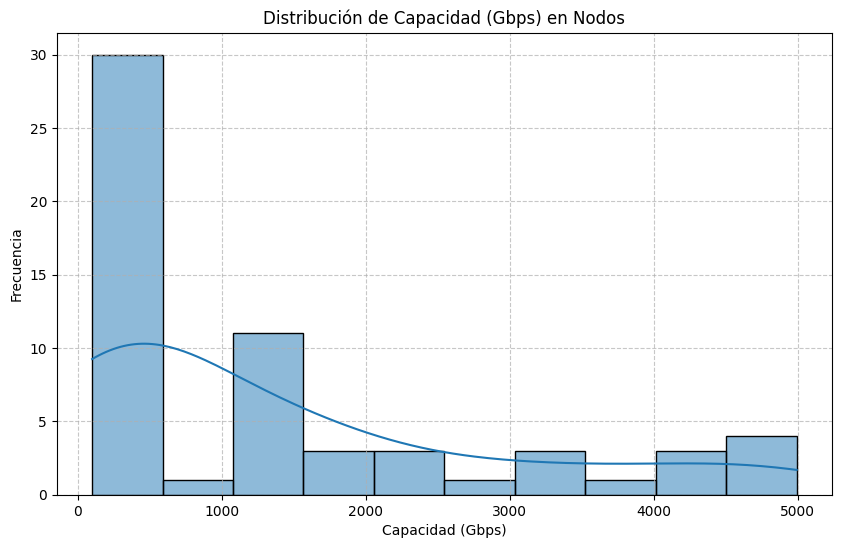

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_nodos_cleaned['Capacidad (Gbps)'], kde=True, bins=10)
plt.title('Distribución de Capacidad (Gbps) en Nodos')
plt.xlabel('Capacidad (Gbps)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comparación de la Distribución de Latencia

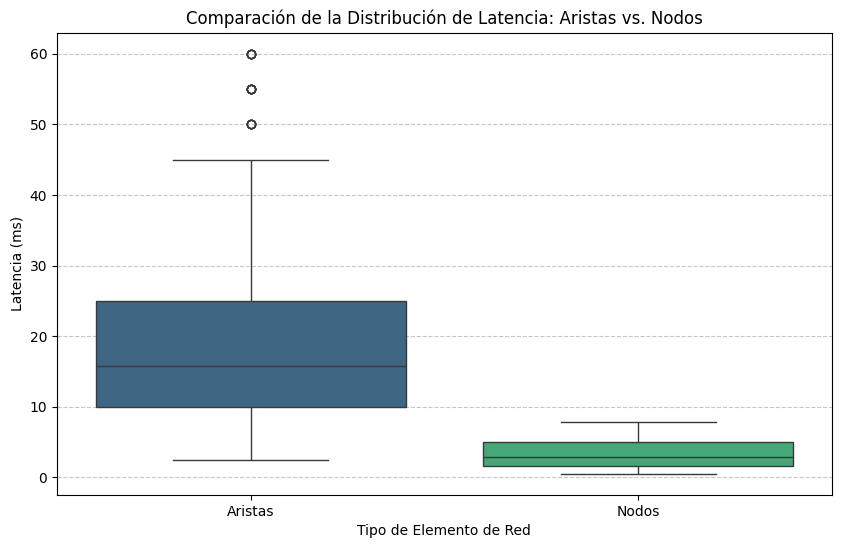

In [42]:
# Prepare data for comparison
latency_aristas = df_aristas_cleaned[['Latency']].copy()
latency_aristas['Tipo'] = 'Aristas'

latency_nodos = df_nodos_cleaned[['Latency']].copy()
latency_nodos['Tipo'] = 'Nodos'

combined_latency = pd.concat([latency_aristas, latency_nodos])

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tipo', y='Latency', data=combined_latency, hue='Tipo', palette='viridis', legend=False)
plt.title('Comparación de la Distribución de Latencia: Aristas vs. Nodos')
plt.xlabel('Tipo de Elemento de Red')
plt.ylabel('Latencia (ms)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Estadísticas Descriptivas de Latencia

In [43]:
print('Estadísticas descriptivas para Latencia en Aristas:')
display(df_aristas_cleaned['Latency'].describe())

print('\nEstadísticas descriptivas para Latencia en Nodos:')
display(df_nodos_cleaned['Latency'].describe())

Estadísticas descriptivas para Latencia en Aristas:


,Latency
count,200.000000
mean,19.490000
std,14.430387
min,2.500000
25%,10.000000
50%,15.750000
75%,25.000000
max,60.000000



Estadísticas descriptivas para Latencia en Nodos:


,Latency
count,60.000000
mean,3.372833
std,2.034986
min,0.530000
25%,1.590000
50%,2.965000
75%,4.970000
max,7.830000


In [36]:
import pandas as pd

### Loading the network data from CSV files

In [37]:
df_aristas = pd.read_csv('/content/red_aristas separadas8.csv')
df_nodos = pd.read_csv('/content/red_nodos_separados9.csv')

print('First 5 rows of df_aristas:')
display(df_aristas.head())

print('\nFirst 5 rows of df_nodos:')
display(df_nodos.head())

First 5 rows of df_aristas:


,Tipo_Elemento,ID_Componente,Origen_u_Fila,Destino_v_Fila,Medio_o_Tipo,Funcion_en_Red,Metrica_Peso_o_Ubicacion,Capacidad_Gbps,Latencia_ms,Importancia_Critica
0,Arista,E_001,Troncal_ISP_5,V5_Netflix,Fibra Óptica Multimodo (Distribución),Distribución,1,400.0,2.5,Media-Alta
1,Arista,E_002,Troncal_ISP_12,Router_Acceso_10,Fibra Óptica Multimodo (Distribución),Distribución,4,400.0,10.0,Media-Alta
2,Arista,E_003,Router_Acceso_7,Router_Acceso_1,Cable de Cobre / Par Trenzado Cat8,Última Milla,12,40.0,60.0,Media
3,Arista,E_004,V5_Google,Troncal_ISP_8,Fibra Óptica Multimodo (Distribución),Distribución,12,400.0,30.0,Media-Alta
4,Arista,E_005,CDN_Cache_8,Nodo_Regional_13,Fibra Óptica Multimodo (Distribución),Distribución,2,400.0,5.0,Media-Alta



First 5 rows of df_nodos:


,Tipo_Elemento,ID_Componente,Medio_o_Tipo,Funcion_en_Red,Metrica_Peso_o_Ubicacion,Capacidad_Gbps,Latencia_ms,Importancia_Critica
0,Nodo,V0_Paracho,Router_Acceso_Regional,Enrutamiento,Red,202.0,6.98,Baja-Media
1,Nodo,V1_RouterLocal,Router_Acceso_Regional,Enrutamiento,Red,370.0,6.66,Baja-Media
2,Nodo,V2_Morelia,Router_Core_Troncal,Enrutamiento,Red,4772.0,2.19,Alta
3,Nodo,V2_Uruapan,Router_Core_Troncal,Enrutamiento,Red,3169.0,1.31,Alta
4,Nodo,V3_ISP_CDMX,Router_Core_Troncal,Enrutamiento,Red,1330.0,1.92,Alta


In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Quantum Virtual Machine

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://quantumai.google/cirq/simulate/quantum_virtual_machine"><img src="https://quantumai.google/site-assets/images/buttons/quantumai_logo_1x.png" />View on QuantumAI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/Cirq/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/download_icon_1x.png" />Download notebook</a>
  </td>
</table>

The quantum virtual machine is a virtual Google quantum processor that you can run circuits on by using the [virtual engine interface](./virtual_engine_interface.ipynb). Behind this interface, it uses simulation with noise data to mimic Google quantum hardware processors with high accuracy: In internal tests, the virtual and actual hardware are within experimental error of each other. Additionally, it supports internal use of the high-performance [qsim](/qsim) simulator, for fast execution of larger circuits. The QVM should be used as a preparation step before running on Google hardware, and as a substitute for Google hardware when it is not available.

If you just want to use the QVM for realistic noisy simulation, you can copy and build upon the [QVM Creation Template](./qvm_builder_code.ipynb), which provides a concise and portable way to instantiate an `Engine` class that you can realistically simulate circuit runs with. After doing so, skip forward to the [How to use a QVM](#how_to_use_a_qvm) section. If you're interested in how the QVM is prepared for use, continue on to the following section.

## Setup

In [ ]:
# @title Install `cirq_google` and `qsimcirq`

try:
    import cirq
    import cirq_google
except ImportError:
    print("installing cirq...")
    !pip install --quiet cirq-google
    print("installed cirq.")
    import cirq
    import cirq_google

try:
    import qsimcirq
except ImportError:
    print("installing qsimcirq...")
    !pip install --quiet qsimcirq
    print(f"installed qsimcirq.")
    import qsimcirq

## How to build a QVM

### Choose a processor to virtualize

Currently, the necessary data is publicly accessible for the [Willow](https://quantumai.google/static/site-assets/downloads/willow-spec-sheet.pdf) processor as well as the older [Weber](https://quantumai.google/hardware/datasheet/weber.pdf) and Rainbow processors.

In [ ]:
# Choose a processor ("willow_pink" or "rainbow" or "weber")
# (see cirq_google.engine.list_virtual_processors() for available names)

processor_id = "willow_pink"

### Build a noisy simulator with a hardware noise model

- Load median device noise data for the processor you have chosen. Learn more about device noise data [here](../noise/representing_noise.ipynb)
- Transform the median device noise data to a Cirq noise properties object
- Create a noise model using your noise properties
- Set up a qsim sampler which runs noisy simulations using your noise model. Learn more about noisy simulation with qsim here in the [Noisy simulation with qsim page](/qsim/tutorials/noisy_qsimcirq).

In [ ]:
# Load the noise properties for the processor.
noise_props = cirq_google.engine.load_device_noise_properties(processor_id)
# Create a noise model from the noise properties.
noise_model = cirq_google.NoiseModelFromGoogleNoiseProperties(noise_props)
# Prepare a qsim simulator using the noise model.
sim = qsimcirq.QSimSimulator(noise=noise_model)

The qsim documentation explains how simulation performance depends on choice of hardware. If you would like use a larger number of qubits on your virtual device (eg 25-32 qubits), parallelizing the simulation over multiple compute nodes is advised. You can do this using Google Cloud hardware as is described in the [qsim Multinode Tutorial](/qsim/tutorials/multinode).

### Set up the virtual engine with a virtual processor, packaging in the noisy simulator
To ensure that the workflow for using a virtual quantum processor is the same as the workflow for using a real quantum processor, a quantum virtual engine implements the same interface as the `cirq.Engine` for used  Google's quantum hardware. Learn more about Google’s quantum engine in the [Quantum Virtual Engine Interface page](./virtual_engine_interface.ipynb).
- Create a device object. Learn more about the device object in Cirq here  in the [Devices page](../hardware/devices.ipynb)
- Create a simulated processor object for the engine to consume (`SimulatedLocalProcessor`)
- Create a virtual engine (`SimulatedLocalEngine`)

In [ ]:
# Package the simulator and device in an Engine.
# The device object
device = cirq_google.engine.create_device_from_processor_id(processor_id)
# Load the median device noise calibration for your processor.
cal = cirq_google.engine.load_median_device_calibration(processor_id)
# The simulated processor object
sim_processor = cirq_google.engine.SimulatedLocalProcessor(
    processor_id=processor_id, sampler=sim, device=device, calibrations={cal.timestamp // 1000: cal}
)
# The virtual engine
sim_engine = cirq_google.engine.SimulatedLocalEngine([sim_processor])
print(
    "Your quantum virtual machine",
    processor_id,
    "is ready, here is the qubit grid:",
    "\n========================\n",
)
print(sim_engine.get_processor(processor_id).get_device())

## How to use a QVM

The following code runs a circuit on your QVM by using the `run` function of a sampler from the simulated engine:

In [ ]:
q0 = cirq.GridQubit(4, 4)
q1 = cirq.GridQubit(4, 5)
circuit = cirq.Circuit(
    cirq.X(q0),
    cirq.X(q1) ** 0.5,
    cirq.CZ(q0, q1),
    cirq.X(q1) ** 0.5,
    cirq.measure([q0, q1], key="measure"),
)

results = sim_engine.get_sampler(processor_id).run(circuit, repetitions=3000)

print(results.histogram(key="measure"))

As in the example linked above, your circuit needs to be “device ready”. This means that:
- The gates in the circuit need to be in the set of legal gates on the device
- The circuit needs to operate on qubits available on the virtual device.
- The topology of your circuit must correspond to the topology of the device (i.e., 2-qubit gates must act on adjacent qubits).

For a hands-on example of the steps necessary to prepare a circuit to be run on the QVM, see the [QVM Basic Example](./qvm_basic_example.ipynb) page.

The steps necessary to make a circuit device-ready are summarized here:
1. Transform your circuit to use the correct gate set with `cirq.optimize_for_target_gateset`. Read [Transformers](../transform/transformers.ipynb) for more on how to modify circuits.
2. Choose qubits on the virtual device for your circuit to run on. The connectivity required by your circuit must be supported by the connectivity present in your chosen qubit set. See [Qubit Picking](../hardware/qubit_picking.ipynb) for more advice.
3. Map your transformed circuit to those qubits with `cirq.Circuit`'s `transform_qubits` function. This may require some careful planning depending on your particular circuit.

You also need to decide on the number of repetitions your circuit will be used in the trajectory simulation. This number determines how accurately the quantum virtual machine will simulate the true quantum state of your circuit. For more details on this see [this paper](https://arxiv.org/abs/2111.02396){:.external}. We recommend using 10,000+ repetitions for research simulations, and 3,000 repetitions for learning simulations. If you are just getting a feel for the tools you can set the number of repetitions lower temporarily (eg 1 to 10) to speed things up.
